# 05 - Perbandingan Semua Model dan Skenario

**Tujuan:** Membandingkan performa semua model (CNN, FCNN, Late Fusion, Intermediate Fusion) pada ketiga skenario penanganan imbalance (B1, B2, B3) untuk menentukan kombinasi terbaik.

**Research Questions:**
- **RQ1:** Bagaimana performa model unimodal CNN?
- **RQ2:** Bagaimana performa model unimodal FCNN?
- **RQ3:** Bagaimana performa model multimodal Late Fusion?
- **RQ4:** Bagaimana performa model multimodal Intermediate Fusion?
- **RQ5:** Model dan skenario mana yang memberikan performa terbaik?

**3 Skenario Imbalance:**
- B1: Tanpa penanganan (baseline)
- B2: Dengan class weights (Cui et al., 2019)
- B3: Dengan class weights + augmentasi

## 1. Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from pathlib import Path

# Project root
PROJECT_ROOT = Path("..").resolve()

# Plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

SCENARIOS = ["B1 Baseline", "B2 Class Weights", "B3 Weights+Aug"]
SCENARIO_SHORT = ["B1", "B2", "B3"]
EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/bs000716/MOTHER-TANK/TRAIN


## 2. Load Results

In [2]:
# Load all results from JSON files
model_dirs = {
    "CNN": PROJECT_ROOT / "models" / "cnn" / "cnn_results.json",
    "FCNN": PROJECT_ROOT / "models" / "fcnn" / "fcnn_results.json",
    "Late Fusion": PROJECT_ROOT / "models" / "late_fusion" / "late_fusion_results.json",
    "Intermediate Fusion": PROJECT_ROOT / "models" / "intermediate_fusion" / "intermediate_fusion_results.json",
}

# Load each and build a combined dictionary
all_results = {}
for model_name, json_path in model_dirs.items():
    if json_path.exists():
        with open(json_path, "r") as f:
            all_results[model_name] = json.load(f)
        print(f"[OK] Loaded {model_name} from {json_path.name}")
    else:
        print(f"[WARN] File not found: {json_path}")

print(f"\nTotal models loaded: {len(all_results)}")

[OK] Loaded CNN from cnn_results.json
[OK] Loaded FCNN from fcnn_results.json
[OK] Loaded Late Fusion from late_fusion_results.json
[OK] Loaded Intermediate Fusion from intermediate_fusion_results.json

Total models loaded: 4


## 3. Summary Table - Semua Model dan Skenario

In [3]:
# Build combined dataframe: 4 models x 3 scenarios = 12 rows
rows = []
for model_name, scenarios in all_results.items():
    for scenario_name, metrics in scenarios.items():
        # Determine short scenario label
        if "B1" in scenario_name:
            skenario = "B1"
        elif "B2" in scenario_name:
            skenario = "B2"
        elif "B3" in scenario_name:
            skenario = "B3"
        else:
            skenario = scenario_name
        
        # Handle different key names (Late Fusion uses test_accuracy, etc.)
        accuracy = metrics.get("accuracy", metrics.get("test_accuracy", 0))
        macro_f1 = metrics.get("macro_f1", metrics.get("test_macro_f1", 0))
        weighted_f1 = metrics.get("weighted_f1", metrics.get("test_weighted_f1", 0))
        
        rows.append({
            "Model": model_name,
            "Skenario": skenario,
            "Accuracy": accuracy,
            "Macro F1": macro_f1,
            "Weighted F1": weighted_f1,
        })

df_summary = pd.DataFrame(rows)
print(f"Total rows: {len(df_summary)} (expected: {len(all_results)} models x 3 scenarios = {len(all_results)*3})")
print()

# Display with styling
styled = df_summary.style \
    .format({"Accuracy": "{:.4f}", "Macro F1": "{:.4f}", "Weighted F1": "{:.4f}"}) \
    .background_gradient(subset=["Macro F1"], cmap="YlGn") \
    .set_caption("Perbandingan Semua Model dan Skenario")
styled

Total rows: 12 (expected: 4 models x 3 scenarios = 12)



,Model,Skenario,Accuracy,Macro F1,Weighted F1
0,CNN,B1,0.8418,0.1329,0.8814
1,CNN,B2,0.8279,0.1335,0.8720
2,CNN,B3,0.6486,0.1194,0.7659
3,FCNN,B1,0.9583,0.2343,0.9524
4,FCNN,B2,0.8913,0.1890,0.9116
5,FCNN,B3,0.9227,0.1817,0.9273
6,Late Fusion,B1,0.9583,0.2298,0.9512
7,Late Fusion,B2,0.8967,0.1888,0.9093
8,Late Fusion,B3,0.9245,0.1823,0.9289
9,Intermediate Fusion,B1,0.6329,0.1115,0.7443


## 4. Best Model per Scenario

In [4]:
# For each scenario (B1, B2, B3), which model performs best?
print("=" * 70)
print("MODEL TERBAIK PER SKENARIO (berdasarkan Macro F1)")
print("=" * 70)

for scenario in SCENARIO_SHORT:
    df_scenario = df_summary[df_summary["Skenario"] == scenario]
    if len(df_scenario) == 0:
        print(f"\n[{scenario}] No data available")
        continue
    
    best_idx = df_scenario["Macro F1"].idxmax()
    best_row = df_scenario.loc[best_idx]
    
    print(f"\n--- Skenario {scenario} ---")
    print(f"  Model terbaik : {best_row['Model']}")
    print(f"  Accuracy      : {best_row['Accuracy']:.4f}")
    print(f"  Macro F1      : {best_row['Macro F1']:.4f}")
    print(f"  Weighted F1   : {best_row['Weighted F1']:.4f}")
    print()
    # Show ranking
    ranking = df_scenario.sort_values("Macro F1", ascending=False).reset_index(drop=True)
    ranking.index = ranking.index + 1  # 1-based ranking
    ranking.index.name = "Rank"
    display(ranking[["Model", "Macro F1", "Accuracy"]])

MODEL TERBAIK PER SKENARIO (berdasarkan Macro F1)

--- Skenario B1 ---
  Model terbaik : FCNN
  Accuracy      : 0.9583
  Macro F1      : 0.2343
  Weighted F1   : 0.9524



,Model,Macro F1,Accuracy
Rank,,,
1,FCNN,0.234280,0.958333
2,Late Fusion,0.229820,0.958333
3,CNN,0.132918,0.841787
4,Intermediate Fusion,0.111479,0.632850



--- Skenario B2 ---
  Model terbaik : FCNN
  Accuracy      : 0.8913
  Macro F1      : 0.1890
  Weighted F1   : 0.9116



,Model,Macro F1,Accuracy
Rank,,,
1,FCNN,0.189035,0.891304
2,Late Fusion,0.188809,0.896739
3,Intermediate Fusion,0.139876,0.844807
4,CNN,0.133529,0.827899



--- Skenario B3 ---
  Model terbaik : Late Fusion
  Accuracy      : 0.9245
  Macro F1      : 0.1823
  Weighted F1   : 0.9289



,Model,Macro F1,Accuracy
Rank,,,
1,Late Fusion,0.182329,0.924517
2,FCNN,0.181747,0.922705
3,Intermediate Fusion,0.133582,0.815821
4,CNN,0.119426,0.648551


## 5. Best Scenario per Model

In [5]:
# For each model, which imbalance strategy works best?
print("=" * 70)
print("SKENARIO TERBAIK PER MODEL (berdasarkan Macro F1)")
print("=" * 70)

model_names = df_summary["Model"].unique()
for model_name in model_names:
    df_model = df_summary[df_summary["Model"] == model_name]
    best_idx = df_model["Macro F1"].idxmax()
    best_row = df_model.loc[best_idx]
    
    print(f"\n--- {model_name} ---")
    print(f"  Skenario terbaik : {best_row['Skenario']}")
    print(f"  Accuracy         : {best_row['Accuracy']:.4f}")
    print(f"  Macro F1         : {best_row['Macro F1']:.4f}")
    print(f"  Weighted F1      : {best_row['Weighted F1']:.4f}")
    print()
    # Show all scenarios for this model
    ranking = df_model.sort_values("Macro F1", ascending=False).reset_index(drop=True)
    ranking.index = ranking.index + 1
    ranking.index.name = "Rank"
    display(ranking[["Skenario", "Macro F1", "Accuracy", "Weighted F1"]])

SKENARIO TERBAIK PER MODEL (berdasarkan Macro F1)

--- CNN ---
  Skenario terbaik : B2
  Accuracy         : 0.8279
  Macro F1         : 0.1335
  Weighted F1      : 0.8720



,Skenario,Macro F1,Accuracy,Weighted F1
Rank,,,,
1,B2,0.133529,0.827899,0.872010
2,B1,0.132918,0.841787,0.881400
3,B3,0.119426,0.648551,0.765884



--- FCNN ---
  Skenario terbaik : B1
  Accuracy         : 0.9583
  Macro F1         : 0.2343
  Weighted F1      : 0.9524



,Skenario,Macro F1,Accuracy,Weighted F1
Rank,,,,
1,B1,0.234280,0.958333,0.952404
2,B2,0.189035,0.891304,0.911625
3,B3,0.181747,0.922705,0.927342



--- Late Fusion ---
  Skenario terbaik : B1
  Accuracy         : 0.9583
  Macro F1         : 0.2298
  Weighted F1      : 0.9512



,Skenario,Macro F1,Accuracy,Weighted F1
Rank,,,,
1,B1,0.229820,0.958333,0.951182
2,B2,0.188809,0.896739,0.909350
3,B3,0.182329,0.924517,0.928877



--- Intermediate Fusion ---
  Skenario terbaik : B2
  Accuracy         : 0.8448
  Macro F1         : 0.1399
  Weighted F1      : 0.8809



,Skenario,Macro F1,Accuracy,Weighted F1
Rank,,,,
1,B2,0.139876,0.844807,0.880921
2,B3,0.133582,0.815821,0.866483
3,B1,0.111479,0.632850,0.744286


## 6. Overall Best - Model + Skenario Terbaik

In [6]:
# Which model + scenario combination gives the highest Macro F1?
best_overall_idx = df_summary["Macro F1"].idxmax()
best_overall = df_summary.loc[best_overall_idx]

print("=" * 70)
print("KOMBINASI TERBAIK SECARA KESELURUHAN")
print("=" * 70)
print(f"  Model           : {best_overall['Model']}")
print(f"  Skenario        : {best_overall['Skenario']}")
print(f"  Accuracy        : {best_overall['Accuracy']:.4f}")
print(f"  Macro F1        : {best_overall['Macro F1']:.4f}")
print(f"  Weighted F1     : {best_overall['Weighted F1']:.4f}")
print("=" * 70)

# Top 5 combinations
print("\nTop 5 Kombinasi:")
top5 = df_summary.sort_values("Macro F1", ascending=False).head(5).reset_index(drop=True)
top5.index = top5.index + 1
top5.index.name = "Rank"
display(top5)

KOMBINASI TERBAIK SECARA KESELURUHAN
  Model           : FCNN
  Skenario        : B1
  Accuracy        : 0.9583
  Macro F1        : 0.2343
  Weighted F1     : 0.9524

Top 5 Kombinasi:


,Model,Skenario,Accuracy,Macro F1,Weighted F1
Rank,,,,,
1,FCNN,B1,0.958333,0.234280,0.952404
2,Late Fusion,B1,0.958333,0.229820,0.951182
3,FCNN,B2,0.891304,0.189035,0.911625
4,Late Fusion,B2,0.896739,0.188809,0.909350
5,Late Fusion,B3,0.924517,0.182329,0.928877


## 7. Visualisasi - Grouped Bar Chart

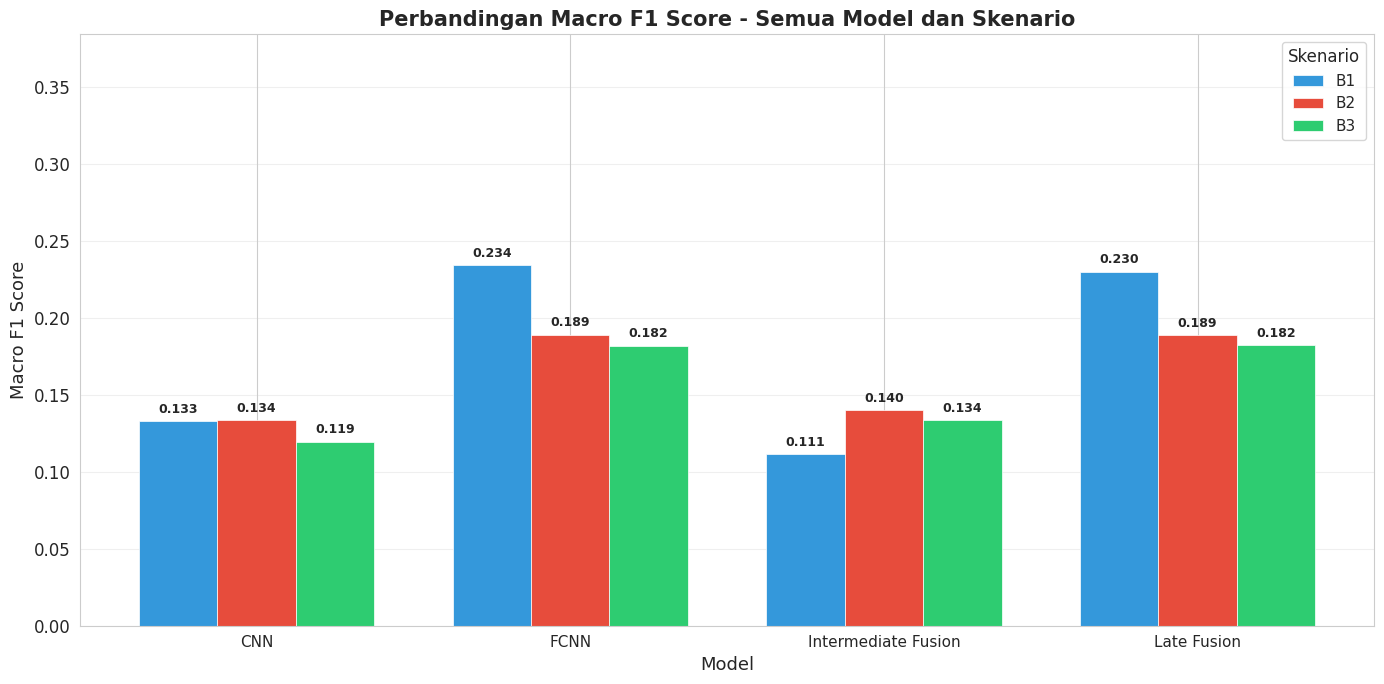

Saved: models/comparison_grouped_bar.png


In [7]:
# Macro F1 per model grouped by scenario (4 groups, 3 bars each)
fig, ax = plt.subplots(figsize=(14, 7))

pivot_f1 = df_summary.pivot(index="Model", columns="Skenario", values="Macro F1")
# Ensure column order is B1, B2, B3
col_order = [s for s in SCENARIO_SHORT if s in pivot_f1.columns]
pivot_f1 = pivot_f1[col_order]

x = np.arange(len(pivot_f1.index))
width = 0.25
colors = ["#3498db", "#e74c3c", "#2ecc71"]

for i, scenario in enumerate(col_order):
    bars = ax.bar(x + i * width, pivot_f1[scenario], width, 
                  label=scenario, color=colors[i], edgecolor="white", linewidth=0.5)
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xlabel("Model", fontsize=13)
ax.set_ylabel("Macro F1 Score", fontsize=13)
ax.set_title("Perbandingan Macro F1 Score - Semua Model dan Skenario", fontsize=15, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(pivot_f1.index, fontsize=11)
ax.legend(title="Skenario", fontsize=11)
ax.set_ylim(0, min(1.0, pivot_f1.max().max() + 0.15))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "models" / "comparison_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: models/comparison_grouped_bar.png")

## 8. Visualisasi - Heatmap

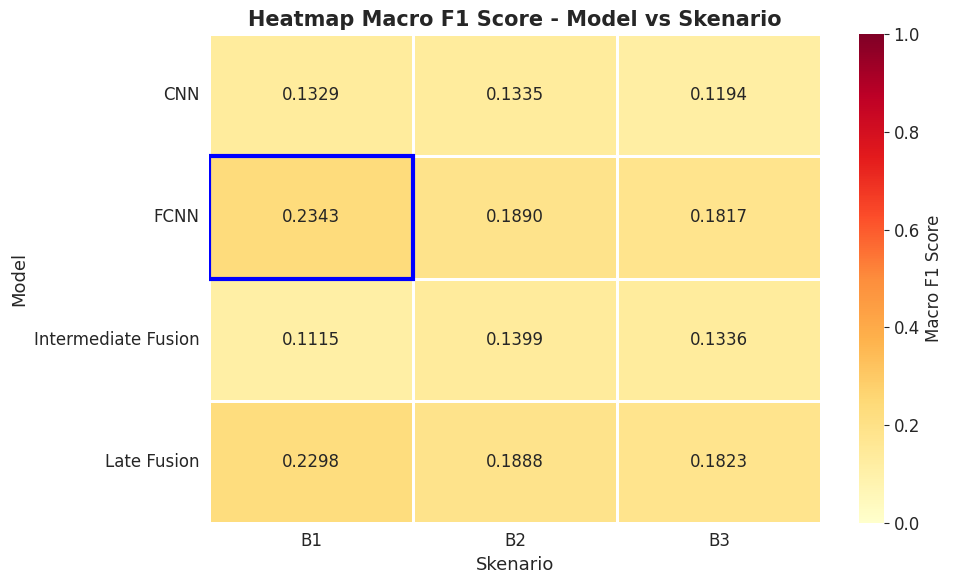

Saved: models/comparison_heatmap.png


In [8]:
# Heatmap of Macro F1 scores (models as rows, scenarios as columns)
fig, ax = plt.subplots(figsize=(10, 6))

pivot_heatmap = df_summary.pivot(index="Model", columns="Skenario", values="Macro F1")
col_order = [s for s in SCENARIO_SHORT if s in pivot_heatmap.columns]
pivot_heatmap = pivot_heatmap[col_order]

sns.heatmap(
    pivot_heatmap,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    linewidths=2,
    linecolor="white",
    cbar_kws={"label": "Macro F1 Score"},
    ax=ax,
    vmin=0,
    vmax=1,
)

# Highlight the best cell
max_val = pivot_heatmap.max().max()
for i in range(len(pivot_heatmap.index)):
    for j in range(len(pivot_heatmap.columns)):
        if pivot_heatmap.iloc[i, j] == max_val:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="blue", linewidth=3))

ax.set_title("Heatmap Macro F1 Score - Model vs Skenario", fontsize=15, fontweight="bold")
ax.set_xlabel("Skenario", fontsize=13)
ax.set_ylabel("Model", fontsize=13)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "models" / "comparison_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: models/comparison_heatmap.png")

## 9. Kesimpulan

### Temuan Utama

Berdasarkan hasil eksperimen pada 4 model x 3 skenario = 12 kombinasi:

1. **Model Terbaik Secara Keseluruhan:** _(diisi setelah eksperimen)_
   - Model: ...
   - Skenario: ...
   - Macro F1: ...

2. **Pengaruh Penanganan Imbalance:**
   - Apakah class weights (B2) meningkatkan performa dibanding baseline (B1)? ...
   - Apakah augmentasi (B3) memberikan peningkatan tambahan? ...

3. **Unimodal vs Multimodal:**
   - Apakah model multimodal (Late/Intermediate Fusion) lebih baik dari unimodal (CNN/FCNN)? ...
   - Tipe fusi mana yang lebih efektif? ...

4. **Rekomendasi:**
   - Model yang direkomendasikan untuk deployment: ...
   - Strategi penanganan imbalance yang direkomendasikan: ...

### Catatan
- Semua evaluasi dilakukan pada test set yang sama
- Metric utama: **Macro F1** (karena dataset imbalanced, macro F1 memberikan bobot yang sama pada setiap kelas)
- Weighted F1 digunakan sebagai metric pendukung

## 10. Save Final Summary

In [9]:
# Save combined results to models/experiment_summary.json
import os

summary_output = {
    "experiment": "Multimodal Emotion Recognition - Full Comparison",
    "models": list(all_results.keys()),
    "scenarios": SCENARIO_SHORT,
    "results": [],
    "best_combination": {
        "model": best_overall["Model"],
        "scenario": best_overall["Skenario"],
        "accuracy": float(best_overall["Accuracy"]),
        "macro_f1": float(best_overall["Macro F1"]),
        "weighted_f1": float(best_overall["Weighted F1"]),
    },
}

# Add all results
for _, row in df_summary.iterrows():
    summary_output["results"].append({
        "model": row["Model"],
        "scenario": row["Skenario"],
        "accuracy": float(row["Accuracy"]),
        "macro_f1": float(row["Macro F1"]),
        "weighted_f1": float(row["Weighted F1"]),
    })

# Sort results by macro_f1 descending
summary_output["results"].sort(key=lambda x: x["macro_f1"], reverse=True)

output_path = PROJECT_ROOT / "models" / "experiment_summary.json"
os.makedirs(output_path.parent, exist_ok=True)

with open(output_path, "w") as f:
    json.dump(summary_output, f, indent=2, ensure_ascii=False)

print(f"Summary saved to: {output_path}")
print(f"Total combinations: {len(summary_output['results'])}")
print()
print("Best combination:")
print(f"  {summary_output['best_combination']['model']} + {summary_output['best_combination']['scenario']}")
print(f"  Macro F1: {summary_output['best_combination']['macro_f1']:.4f}")

Summary saved to: /home/bs000716/MOTHER-TANK/TRAIN/models/experiment_summary.json
Total combinations: 12

Best combination:
  FCNN + B1
  Macro F1: 0.2343
